# 02 — Analyse exploratoire, contrôle qualité et enrichissement des données

Ce notebook constitue le support principal d'analyse exploratoire du projet.  
Il a pour objectifs de :

- contrôler la qualité du dataset principal et du dataset secondaire consolidé ;
- documenter les choix de nettoyage retenus ;
- analyser la structure des rendements et des variables explicatives ;
- réaliser une ACP sur le dataset principal et une ACP sur le dataset secondaire ;
- construire les variables de profil utilisées ensuite dans la modélisation ;
- exporter les datasets préparés pour les notebooks de modélisation.

## Entrées

- `data/raw_local/Agriculture Crop Yield/crop_yield.csv`
- `data/processed/yield_dataset_consolidated.csv`

## Sorties

- `data/processed/crop_aux_clean.csv`
- `data/processed/crop_aux_enriched.csv`
- `data/processed/crop_profile.csv`

## Positionnement dans la démarche

Le notebook `01_eda_sources.ipynb` formalise l'audit des sources et la consolidation du dataset secondaire.  
Le présent notebook prend le relais pour l'analyse exploratoire, le contrôle qualité et la préparation des jeux de données utilisés en modélisation.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from project_paths import PROCESSED_DIR, RAW_DIR
from src.data_manage.load_data import load_csv

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 1. Chargement des jeux de données

Le dataset principal correspond à la base agronomique utilisée pour le modèle principal.  
Le dataset secondaire correspond à la base consolidée issue du notebook `01`, utilisée pour les profils externes et le modèle secondaire.

In [2]:
crop_aux = load_csv("Agriculture Crop Yield/crop_yield.csv").copy()
final_df = pd.read_csv(PROCESSED_DIR / "yield_dataset_consolidated.csv").copy()

target_col = "Yield_tons_per_hectare"

print("Dataset principal :", crop_aux.shape)
print("Dataset secondaire consolidé :", final_df.shape)

Dataset principal : (1000000, 10)
Dataset secondaire consolidé : (13136, 8)


In [3]:
def display_overview(df, name, n=5):
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape :", df.shape)
    display(df.head(n))
    display(df.describe(include="all").T)

display_overview(crop_aux, "Aperçu — dataset principal")
display_overview(final_df, "Aperçu — dataset secondaire consolidé")


Aperçu — dataset principal
--------------------------
Shape : (1000000, 10)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,1000000,4,North,250173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil_Type,1000000,6,Sandy,167119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,1000000,6,Maize,166824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rainfall_mm,1000000.0,NaN,NaN,NaN,549.981901,259.85132,100.000896,324.89109,550.124061,774.73852,999.998098
Temperature_Celsius,1000000.0,NaN,NaN,NaN,27.504965,7.220608,15.000034,21.254502,27.507365,33.753267,39.999997
Fertilizer_Used,1000000,2,False,500060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Irrigation_Used,1000000,2,False,500509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather_Condition,1000000,3,Sunny,333790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days_to_Harvest,1000000.0,NaN,NaN,NaN,104.495025,25.953412,60.0,82.0,104.0,127.0,149.0
Yield_tons_per_hectare,1000000.0,NaN,NaN,NaN,4.649472,1.696572,-1.147613,3.417637,4.651808,5.8792,9.963372



Aperçu — dataset secondaire consolidé
-------------------------------------
Shape : (13136, 8)


,Area,Item,Year,Unit,hg/ha_yield,pesticides_tonnes,average_rain_fall_mm_per_year,avg_temp
0,Albania,Maize,1990,hg/ha,36613,121.0,1485.0,16.37
1,Albania,Maize,1991,hg/ha,29068,121.0,1485.0,15.36
2,Albania,Maize,1992,hg/ha,24876,121.0,1485.0,16.06
3,Albania,Maize,1993,hg/ha,24185,121.0,1485.0,16.05
4,Albania,Maize,1994,hg/ha,25848,201.0,1485.0,16.96


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area,13136,101,Cameroon,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,13136,10,Potatoes,2091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,13136.0,NaN,NaN,NaN,2001.617692,7.035556,1990.0,1995.0,2001.0,2008.0,2013.0
Unit,13136,1,hg/ha,13136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hg/ha_yield,13136.0,NaN,NaN,NaN,70959.63444,79111.427638,50.0,18000.0,39536.0,97159.0,501412.0
pesticides_tonnes,13136.0,NaN,NaN,NaN,14832.141503,33646.165696,0.04,264.5825,2170.4,13335.22,367778.0
average_rain_fall_mm_per_year,13130.0,NaN,NaN,NaN,1157.238766,743.622488,51.0,608.0,1083.0,1651.0,3240.0
avg_temp,13136.0,NaN,NaN,NaN,19.839209,6.657741,1.3,15.67,20.62,25.78,30.42


## 2. Contrôle qualité du dataset principal

La variable cible fait l'objet d'un contrôle spécifique.  
Les valeurs négatives de rendement sont considérées comme incohérentes pour l'usage métier et sont retirées avant toute phase de modélisation.

In [4]:
print("Shape avant nettoyage :", crop_aux.shape)
print("Nombre de valeurs négatives dans la cible :", (crop_aux[target_col] < 0).sum())
print("Minimum observé avant nettoyage :", crop_aux[target_col].min())

display(crop_aux[crop_aux[target_col] < 0].head())

Shape avant nettoyage : (1000000, 10)
Nombre de valeurs négatives dans la cible : 231
Minimum observé avant nettoyage : -1.147613222534901


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
756,East,Peaty,Cotton,101.019421,33.804131,False,False,Rainy,117,-0.007103
7799,South,Chalky,Rice,108.804894,18.004082,False,False,Sunny,86,-0.061283
8421,East,Chalky,Soybean,168.120735,38.473430,False,False,Cloudy,111,-0.119911
9553,North,Silt,Wheat,156.607973,16.610257,False,False,Sunny,129,-0.193093
15435,South,Chalky,Maize,177.481344,27.719742,False,False,Sunny,94,-0.009811


In [5]:
crop_aux = crop_aux.loc[crop_aux[target_col] >= 0].copy()

print("Shape après suppression des valeurs négatives :", crop_aux.shape)
print("Minimum observé après nettoyage :", crop_aux[target_col].min())

assert (crop_aux[target_col] >= 0).all(), "La cible contient encore des valeurs négatives."

Shape après suppression des valeurs négatives : (999769, 10)
Minimum observé après nettoyage : 0.0004108724039286


In [6]:
missing_main = (
    crop_aux.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(missing_main)

,missing_rate
Region,0.0
Soil_Type,0.0
Crop,0.0
Rainfall_mm,0.0
Temperature_Celsius,0.0
Fertilizer_Used,0.0
Irrigation_Used,0.0
Weather_Condition,0.0
Days_to_Harvest,0.0
Yield_tons_per_hectare,0.0


## 3. Analyse exploratoire du dataset principal

Cette section décrit la distribution du rendement et quelques relations simples avec les variables agronomiques.
L'objectif n'est pas d'épuiser toutes les lectures possibles, mais d'identifier les premiers signaux utiles pour la modélisation.

,count,mean,std,min,25%,50%,75%,max
Yield_tons_per_hectare,999769.0,4.650592,1.695166,0.000411,3.418669,4.652333,5.879576,9.963372


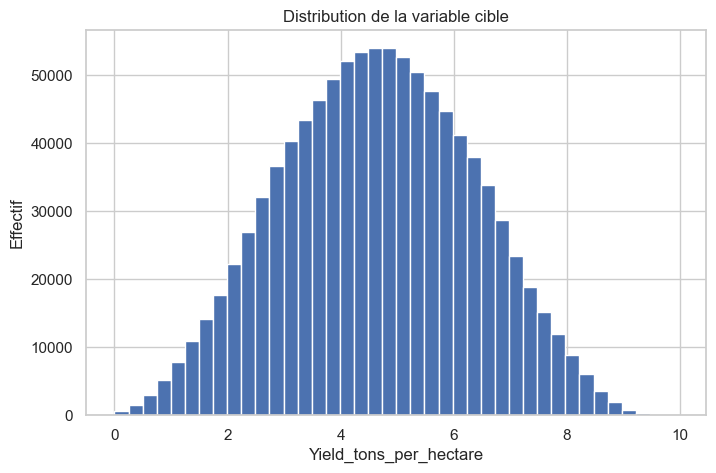

In [7]:
display(crop_aux[[target_col]].describe().T)

plt.figure(figsize=(8, 5))
plt.hist(crop_aux[target_col], bins=40)
plt.xlabel("Yield_tons_per_hectare")
plt.ylabel("Effectif")
plt.title("Distribution de la variable cible")
plt.show()

,count,mean,median,std
Crop,,,,
Soybean,166315,4.654701,4.657997,1.695533
Wheat,166640,4.653722,4.655996,1.693550
Cotton,166548,4.651918,4.651403,1.694011
Rice,166754,4.651849,4.653379,1.696802
Barley,166727,4.648864,4.651196,1.696475
Maize,166785,4.642513,4.643244,1.694621


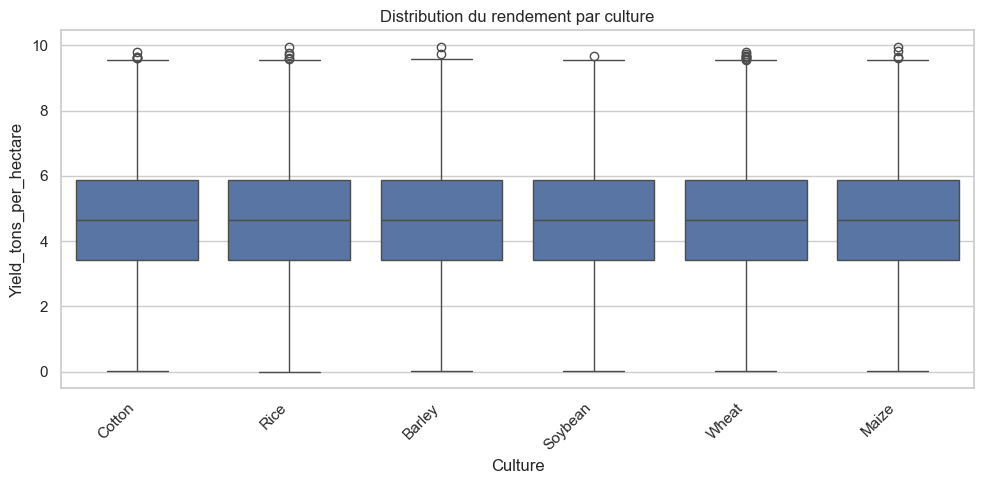

In [8]:
crop_summary = (
    crop_aux.groupby("Crop", dropna=False)[target_col]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(crop_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=crop_aux, x="Crop", y=target_col)
plt.title("Distribution du rendement par culture")
plt.xlabel("Culture")
plt.ylabel("Yield_tons_per_hectare")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
Rainfall_mm,1.000000,-0.000371,-0.002678,0.764512
Temperature_Celsius,-0.000371,1.000000,-0.000754,0.085213
Days_to_Harvest,-0.002678,-0.000754,1.000000,-0.002605
Yield_tons_per_hectare,0.764512,0.085213,-0.002605,1.000000


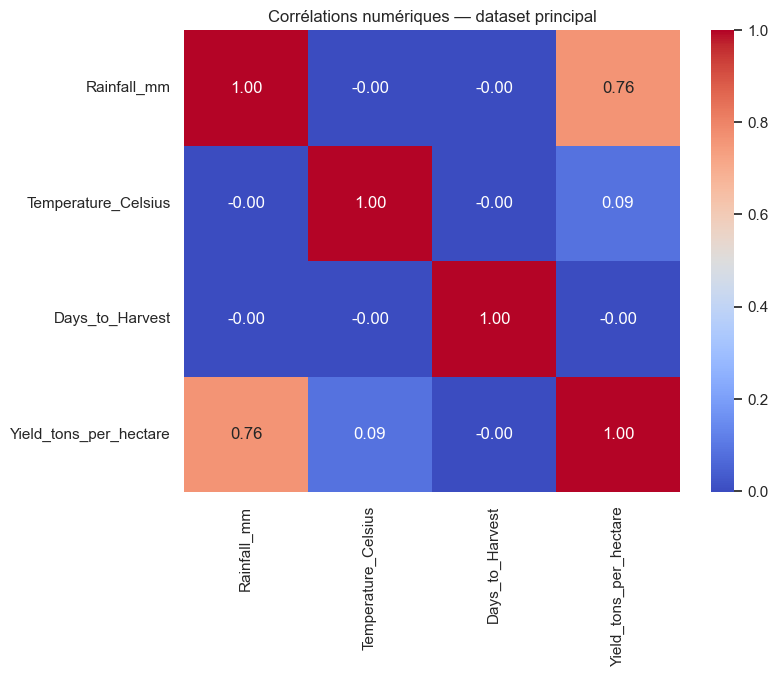

In [9]:
numeric_main = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Yield_tons_per_hectare",
]

corr_main = crop_aux[numeric_main].corr()
display(corr_main)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_main, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations numériques — dataset principal")
plt.show()

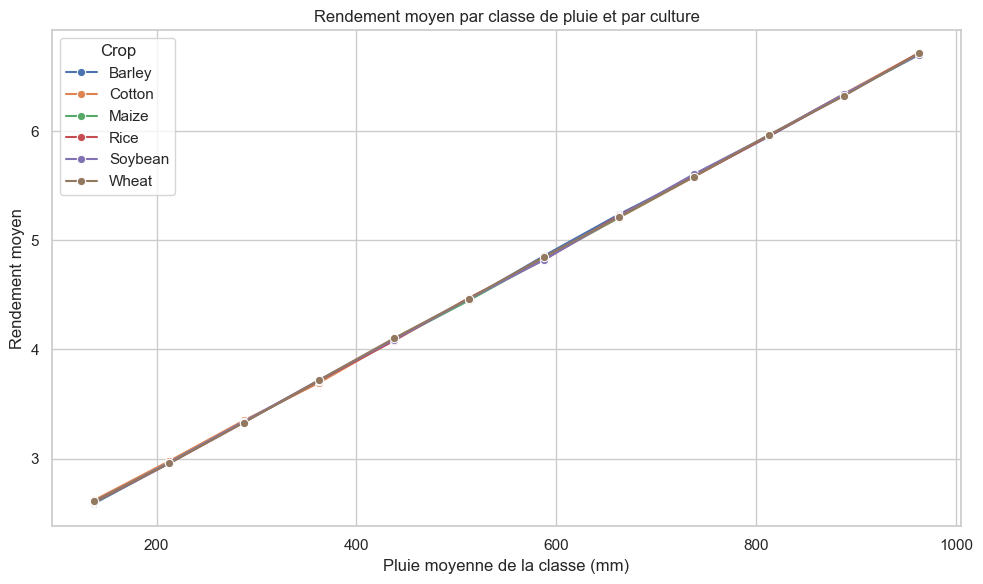

In [10]:
rain_curve = (
    crop_aux[["Crop", "Rainfall_mm", target_col]]
    .dropna()
    .assign(rain_bin=lambda df: pd.cut(df["Rainfall_mm"], bins=12))
    .groupby(["Crop", "rain_bin"], observed=False)
    .agg(
        rainfall_mid=("Rainfall_mm", "mean"),
        mean_yield=(target_col, "mean"),
        n_obs=(target_col, "size"),
    )
    .reset_index()
    .dropna(subset=["rainfall_mid", "mean_yield"])
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=rain_curve, x="rainfall_mid", y="mean_yield", hue="Crop", marker="o")
plt.title("Rendement moyen par classe de pluie et par culture")
plt.xlabel("Pluie moyenne de la classe (mm)")
plt.ylabel("Rendement moyen")
plt.tight_layout()
plt.show()

## 4. ACP exploratoire sur le dataset principal

Une ACP est réalisée sur le dataset principal afin d'examiner la structuration des observations dans un espace réduit.
Cette ACP relève de l'exploration et n'implique pas à elle seule une décision de modélisation.

In [11]:
crop_aux_pca = crop_aux.copy()
crop_aux_pca["Fertilizer_Used_num"] = crop_aux_pca["Fertilizer_Used"].astype(int)
crop_aux_pca["Irrigation_Used_num"] = crop_aux_pca["Irrigation_Used"].astype(int)

pca_main_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Fertilizer_Used_num",
    "Irrigation_Used_num",
    "Yield_tons_per_hectare",
]

X_main_pca = crop_aux_pca[pca_main_features].dropna().copy()
y_main_pca = crop_aux_pca.loc[X_main_pca.index, "Crop"].copy()

scaler_main = StandardScaler()
X_main_scaled = scaler_main.fit_transform(X_main_pca)

pca_main = PCA()
X_main_proj = pca_main.fit_transform(X_main_scaled)

explained_main = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_main.explained_variance_ratio_))],
    "explained_variance_ratio": pca_main.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_main.explained_variance_ratio_),
})

display(explained_main)

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.325738,0.325738
1,PC2,0.167179,0.492917
2,PC3,0.166816,0.659734
3,PC4,0.166670,0.826404
4,PC5,0.166182,0.992586
5,PC6,0.007414,1.000000


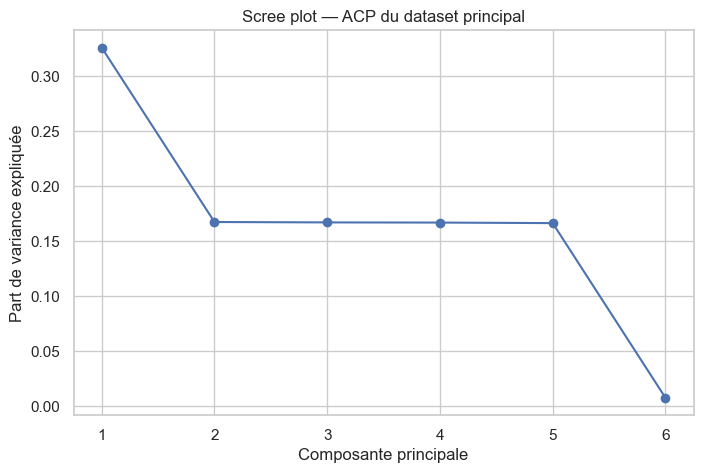

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_main.explained_variance_ratio_) + 1),
    pca_main.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Composante principale")
plt.ylabel("Part de variance expliquée")
plt.title("Scree plot — ACP du dataset principal")
plt.show()

C:\Users\thoma\AppData\Local\Temp\ipykernel_34868\2579611907.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


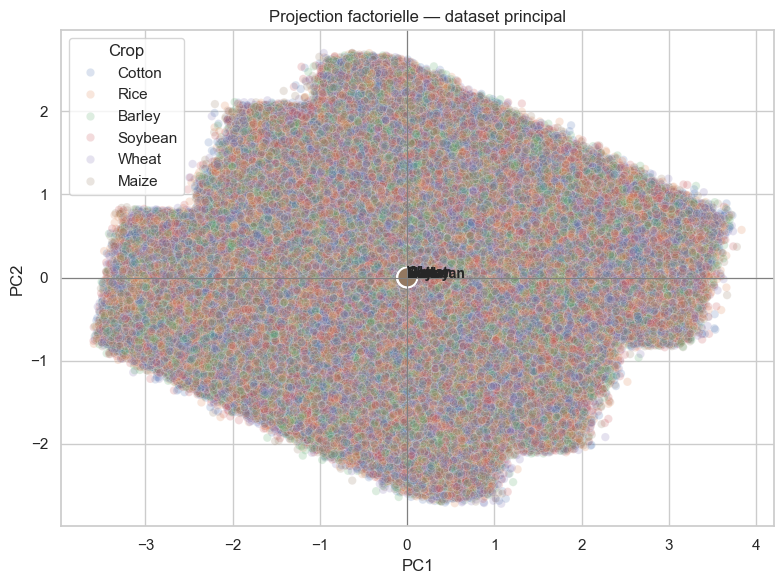

,PC1,PC2
Rainfall_mm,0.565796,-0.554109
Temperature_Celsius,0.063508,0.443250
Days_to_Harvest,-0.004262,0.041472
Fertilizer_Used_num,0.327131,0.640049
Irrigation_Used_num,0.261784,0.291737
Yield_tons_per_hectare,0.707304,-0.000301


In [13]:
scores_main = pd.DataFrame(X_main_proj[:, :2], columns=["PC1", "PC2"], index=X_main_pca.index)
scores_main["Crop"] = y_main_pca.values

centroids_main = (
    scores_main.groupby("Crop")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scores_main, x="PC1", y="PC2", hue="Crop", alpha=0.20)
sns.scatterplot(data=centroids_main, x="PC1", y="PC2", hue="Crop", s=200, legend=False)
for _, row in centroids_main.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Crop"], fontsize=10, weight="bold")
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Projection factorielle — dataset principal")
plt.tight_layout()
plt.show()

loadings_main = pd.DataFrame(
    pca_main.components_.T,
    index=pca_main_features,
    columns=[f"PC{i+1}" for i in range(len(pca_main_features))],
)

display(loadings_main.loc[:, ["PC1", "PC2"]])

## 5. Analyse exploratoire du dataset secondaire consolidé

Le dataset secondaire est mobilisé à la fois pour l'exploration et pour la construction de profils externes par culture.
Une conversion explicite du rendement est réalisée afin d'exprimer les ordres de grandeur dans la même unité que le dataset principal.

In [14]:
final_df["yield_tons_per_hectare"] = final_df["hg/ha_yield"] / 10000

print("Année min :", final_df["Year"].min())
print("Année max :", final_df["Year"].max())
print("Nombre d'années :", final_df["Year"].nunique())

display(final_df["Item"].value_counts().head(15).rename("count").to_frame())
display(final_df["Area"].value_counts().head(15).rename("count").to_frame())
display(final_df[["yield_tons_per_hectare"]].describe().T)

Année min : 1990
Année max : 2013
Nombre d'années : 23


,count
Item,
Potatoes,2091
Maize,2030
Wheat,1810
"Rice, paddy",1502
Sorghum,1435
Soybeans,1242
Sweet potatoes,1165
Cassava,943
Plantains and others,464


,count
Area,
Cameroon,230
Kenya,230
Colombia,207
Brazil,207
Burundi,207
Peru,207
Rwanda,207
Mali,207
Uganda,207


,count,mean,std,min,25%,50%,75%,max
yield_tons_per_hectare,13136.0,7.095963,7.911143,0.005,1.8,3.9536,9.7159,50.1412


,yield_tons_per_hectare,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
yield_tons_per_hectare,1.000000,0.013157,-0.143493,0.092247
average_rain_fall_mm_per_year,0.013157,1.000000,0.344231,0.077260
avg_temp,-0.143493,0.344231,1.000000,-0.104982
pesticides_tonnes,0.092247,0.077260,-0.104982,1.000000


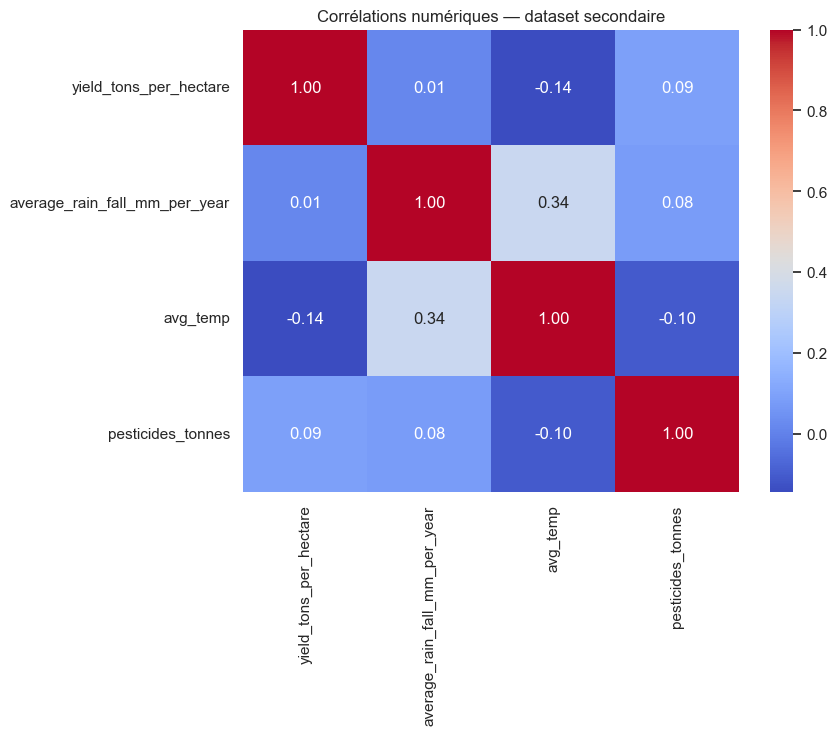

In [15]:
numeric_secondary = [
    "yield_tons_per_hectare",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "pesticides_tonnes",
]

corr_secondary = final_df[numeric_secondary].corr()
display(corr_secondary)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_secondary, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations numériques — dataset secondaire")
plt.show()

## 6. ACP exploratoire sur le dataset secondaire

L'ACP du dataset secondaire est réalisée sur le sous-ensemble de cultures effectivement raccordables au dataset principal.
L'objectif est d'examiner la structure des profils externes avant leur réutilisation dans la phase d'enrichissement.

In [16]:
crop_mapping = {
    "Maize": "Maize",
    "Rice, paddy": "Rice",
    "Soybeans": "Soybean",
    "Wheat": "Wheat",
}

final_df_profile = final_df.copy()
final_df_profile["Crop"] = final_df_profile["Item"].map(crop_mapping)

secondary_pca_df = final_df_profile.loc[final_df_profile["Crop"].notna()].copy()

pca_secondary_features = [
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "pesticides_tonnes",
    "yield_tons_per_hectare",
]

X_secondary_pca = secondary_pca_df[pca_secondary_features].dropna().copy()
y_secondary_pca = secondary_pca_df.loc[X_secondary_pca.index, "Crop"].copy()

scaler_secondary = StandardScaler()
X_secondary_scaled = scaler_secondary.fit_transform(X_secondary_pca)

pca_secondary = PCA()
X_secondary_proj = pca_secondary.fit_transform(X_secondary_scaled)

explained_secondary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_secondary.explained_variance_ratio_))],
    "explained_variance_ratio": pca_secondary.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_secondary.explained_variance_ratio_),
})

display(explained_secondary)

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.382333,0.382333
1,PC2,0.279088,0.661421
2,PC3,0.197457,0.858878
3,PC4,0.141122,1.000000


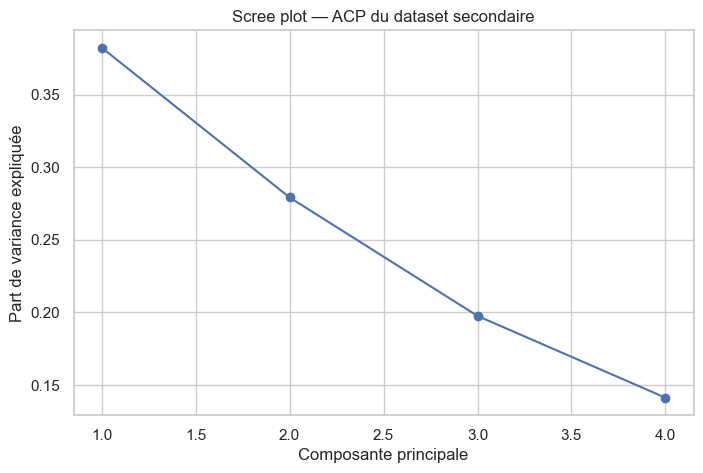

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_secondary.explained_variance_ratio_) + 1),
    pca_secondary.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Composante principale")
plt.ylabel("Part de variance expliquée")
plt.title("Scree plot — ACP du dataset secondaire")
plt.show()

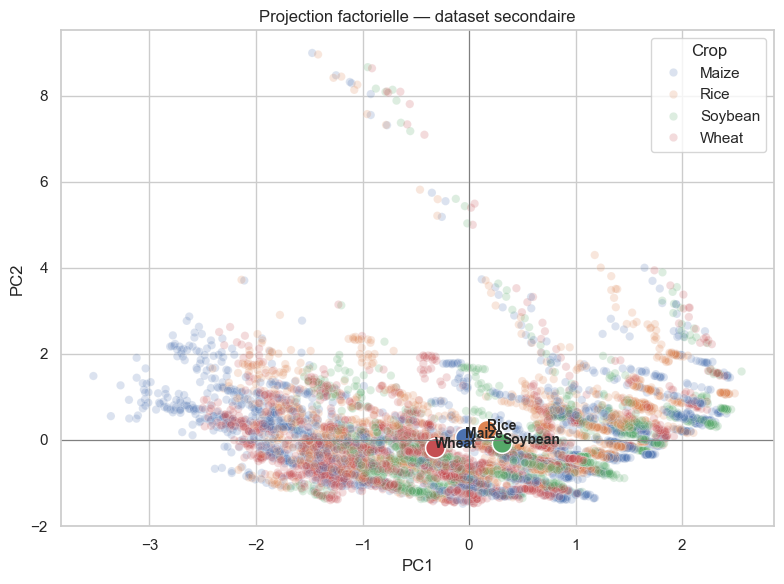

,PC1,PC2
average_rain_fall_mm_per_year,0.483870,0.542986
avg_temp,0.669170,0.077131
pesticides_tonnes,-0.172247,0.763787
yield_tons_per_hectare,-0.537041,0.340362


In [18]:
scores_secondary = pd.DataFrame(
    X_secondary_proj[:, :2],
    columns=["PC1", "PC2"],
    index=X_secondary_pca.index,
)
scores_secondary["Crop"] = y_secondary_pca.values

centroids_secondary = (
    scores_secondary.groupby("Crop")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scores_secondary, x="PC1", y="PC2", hue="Crop", alpha=0.20)
sns.scatterplot(data=centroids_secondary, x="PC1", y="PC2", hue="Crop", s=200, legend=False)
for _, row in centroids_secondary.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Crop"], fontsize=10, weight="bold")
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Projection factorielle — dataset secondaire")
plt.tight_layout()
plt.show()

loadings_secondary = pd.DataFrame(
    pca_secondary.components_.T,
    index=pca_secondary_features,
    columns=[f"PC{i+1}" for i in range(len(pca_secondary_features))],
)

display(loadings_secondary.loc[:, ["PC1", "PC2"]])

## 7. Construction des profils externes par culture

Les profils externes servent à enrichir le dataset principal avec des tendances moyennes observées dans la base secondaire.
Seules les cultures effectivement raccordables au dataset principal sont retenues.

In [19]:
crop_profile = (
    final_df_profile.loc[final_df_profile["Crop"].notna()]
    .groupby("Crop", as_index=False)
    .agg(
        ext_mean_temp_by_crop=("avg_temp", "mean"),
        ext_mean_rainfall_by_crop=("average_rain_fall_mm_per_year", "mean"),
        ext_mean_pesticides_by_crop=("pesticides_tonnes", "mean"),
        ext_n_obs_by_crop=("Item", "size"),
        ext_mean_yield_tons_per_hectare=("yield_tons_per_hectare", "mean"),
    )
)

display(crop_profile)

,Crop,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,ext_mean_yield_tons_per_hectare
0,Maize,19.248136,1105.724852,13722.443030,2030,3.695952
1,Rice,20.798107,1221.097204,16443.811451,1502,3.754165
2,Soybean,18.225843,1135.826087,20043.068696,1242,1.656375
3,Wheat,16.394240,906.194475,15075.697000,1810,3.078299


In [20]:
crop_aux_profile = (
    crop_aux[crop_aux["Crop"].isin(crop_profile["Crop"])]
    .groupby("Crop", as_index=False)
    .agg(
        aux_mean_yield=("Yield_tons_per_hectare", "mean"),
        aux_mean_rainfall=("Rainfall_mm", "mean"),
        aux_mean_temp=("Temperature_Celsius", "mean"),
        aux_mean_days_to_harvest=("Days_to_Harvest", "mean"),
        aux_fertilizer_rate=("Fertilizer_Used", "mean"),
        aux_irrigation_rate=("Irrigation_Used", "mean"),
        aux_n_obs=("Crop", "size"),
    )
)

comparison_table = crop_aux_profile.merge(crop_profile, on="Crop", how="left")
display(comparison_table)

,Crop,aux_mean_yield,aux_mean_rainfall,aux_mean_temp,aux_mean_days_to_harvest,aux_fertilizer_rate,aux_irrigation_rate,aux_n_obs,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,ext_mean_yield_tons_per_hectare
0,Maize,4.642513,549.291189,27.478547,104.538292,0.498570,0.500075,166785,19.248136,1105.724852,13722.443030,2030,3.695952
1,Rice,4.651849,550.605746,27.499657,104.499778,0.500498,0.496504,166754,20.798107,1221.097204,16443.811451,1502,3.754165
2,Soybean,4.654701,550.559846,27.510413,104.457139,0.499883,0.500881,166315,18.225843,1135.826087,20043.068696,1242,1.656375
3,Wheat,4.653722,550.330008,27.517093,104.516491,0.501254,0.500906,166640,16.394240,906.194475,15075.697000,1810,3.078299


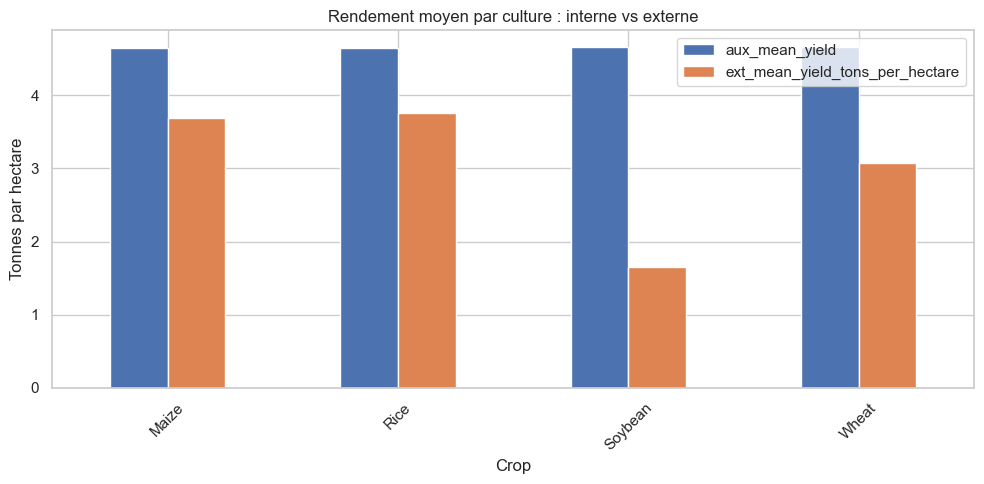

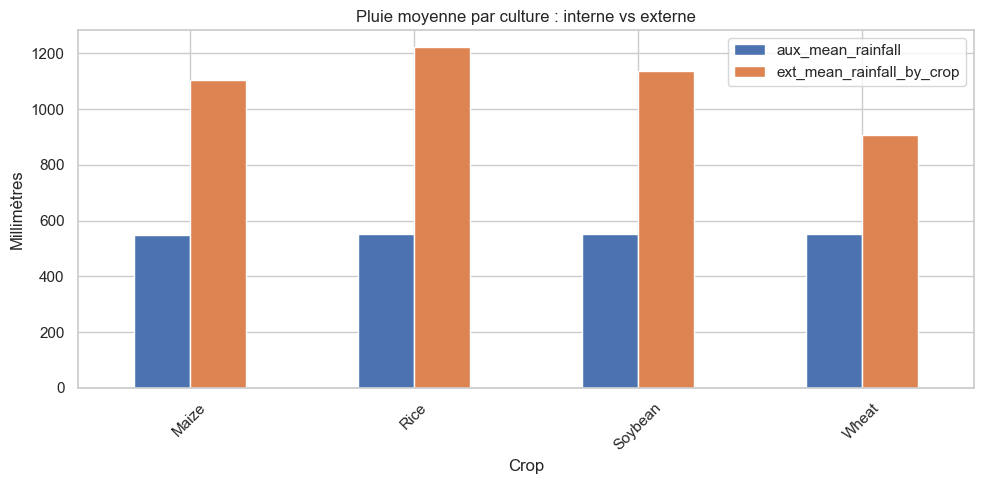

In [21]:
plot_yield = comparison_table[[
    "Crop",
    "aux_mean_yield",
    "ext_mean_yield_tons_per_hectare",
]].set_index("Crop")

plot_yield.plot(kind="bar", figsize=(10, 5))
plt.title("Rendement moyen par culture : interne vs externe")
plt.ylabel("Tonnes par hectare")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plot_rain = comparison_table[[
    "Crop",
    "aux_mean_rainfall",
    "ext_mean_rainfall_by_crop",
]].set_index("Crop")

plot_rain.plot(kind="bar", figsize=(10, 5))
plt.title("Pluie moyenne par culture : interne vs externe")
plt.ylabel("Millimètres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Construction du dataset principal enrichi

Le dataset principal est enrichi par fusion avec les profils externes.
Des variables d'écart au profil sont ensuite calculées, car elles permettent de mesurer la distance entre une observation et la tendance moyenne associée à sa culture.

In [22]:
crop_aux_clean = crop_aux.copy()

crop_aux_enriched = crop_aux_clean.merge(
    crop_profile,
    on="Crop",
    how="left",
)

crop_aux_enriched["rainfall_gap_vs_crop_profile"] = (
    crop_aux_enriched["Rainfall_mm"] - crop_aux_enriched["ext_mean_rainfall_by_crop"]
)

crop_aux_enriched["temp_gap_vs_crop_profile"] = (
    crop_aux_enriched["Temperature_Celsius"] - crop_aux_enriched["ext_mean_temp_by_crop"]
)

display(crop_aux_enriched.head())

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,ext_mean_yield_tons_per_hectare,rainfall_gap_vs_crop_profile,temp_gap_vs_crop_profile
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341,20.798107,1221.097204,16443.811451,1502.0,3.754165,-228.423922,-2.771965
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573,18.225843,1135.826087,20043.068696,1242.0,1.656375,-148.959756,-1.581653
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251,16.394240,906.194475,15075.697000,1810.0,3.078299,-175.815301,15.226447


In [23]:
coverage_check = (
    crop_aux_enriched.groupby("Crop")[[
        "ext_mean_temp_by_crop",
        "ext_mean_rainfall_by_crop",
        "ext_mean_pesticides_by_crop",
        "ext_n_obs_by_crop",
        "rainfall_gap_vs_crop_profile",
        "temp_gap_vs_crop_profile",
    ]]
    .apply(lambda x: x.isna().mean())
)

display(coverage_check)

,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,rainfall_gap_vs_crop_profile,temp_gap_vs_crop_profile
Crop,,,,,,
Barley,1.0,1.0,1.0,1.0,1.0,1.0
Cotton,1.0,1.0,1.0,1.0,1.0,1.0
Maize,0.0,0.0,0.0,0.0,0.0,0.0
Rice,0.0,0.0,0.0,0.0,0.0,0.0
Soybean,0.0,0.0,0.0,0.0,0.0,0.0
Wheat,0.0,0.0,0.0,0.0,0.0,0.0


## 9. Synthèse optionnelle des profils par ACP

Une ACP supplémentaire est appliquée aux profils externes agrégés afin de produire deux variables synthétiques (`crop_profile_pc1`, `crop_profile_pc2`).
Ces variables sont conservées pour les benchmarks de modélisation, tout en restant explicitement optionnelles dans la décision finale.

In [24]:
profile_pca_features = [
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
]

profile_pca_df = crop_profile[["Crop"] + profile_pca_features].dropna().copy()

scaler_profile = StandardScaler()
X_profile_scaled = scaler_profile.fit_transform(profile_pca_df[profile_pca_features])

pca_profile = PCA(n_components=2)
X_profile_proj = pca_profile.fit_transform(X_profile_scaled)

profile_pca_scores = pd.DataFrame({
    "Crop": profile_pca_df["Crop"].values,
    "crop_profile_pc1": X_profile_proj[:, 0],
    "crop_profile_pc2": X_profile_proj[:, 1],
})

profile_pca_loadings = pd.DataFrame(
    pca_profile.components_.T,
    index=profile_pca_features,
    columns=["PC1", "PC2"],
)

display(profile_pca_scores)
display(profile_pca_loadings)

,Crop,crop_profile_pc1,crop_profile_pc2
0,Maize,-1.026438,1.380414
1,Rice,1.438031,1.064397
2,Soybean,1.604274,-1.392803
3,Wheat,-2.015868,-1.052009


,PC1,PC2
ext_mean_temp_by_crop,0.406175,0.624079
ext_mean_rainfall_by_crop,0.547206,0.413976
ext_mean_pesticides_by_crop,0.492923,-0.511665
ext_n_obs_by_crop,-0.540938,0.421127


In [25]:
crop_profile = crop_profile.merge(profile_pca_scores, on="Crop", how="left")
crop_aux_enriched = crop_aux_enriched.merge(profile_pca_scores, on="Crop", how="left")

display(crop_profile)
display(crop_aux_enriched[[
    "Crop",
    "crop_profile_pc1",
    "crop_profile_pc2",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]].head())

,Crop,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,ext_mean_yield_tons_per_hectare,crop_profile_pc1,crop_profile_pc2
0,Maize,19.248136,1105.724852,13722.443030,2030,3.695952,-1.026438,1.380414
1,Rice,20.798107,1221.097204,16443.811451,1502,3.754165,1.438031,1.064397
2,Soybean,18.225843,1135.826087,20043.068696,1242,1.656375,1.604274,-1.392803
3,Wheat,16.394240,906.194475,15075.697000,1810,3.078299,-2.015868,-1.052009


,Crop,crop_profile_pc1,crop_profile_pc2,rainfall_gap_vs_crop_profile,temp_gap_vs_crop_profile
0,Cotton,NaN,NaN,NaN,NaN
1,Rice,1.438031,1.064397,-228.423922,-2.771965
2,Barley,NaN,NaN,NaN,NaN
3,Soybean,1.604274,-1.392803,-148.959756,-1.581653
4,Wheat,-2.015868,-1.052009,-175.815301,15.226447


## 10. Export des datasets préparés

Les trois artefacts exportés à l'issue de ce notebook sont :
- le dataset principal nettoyé ;
- le dataset principal enrichi ;
- la table agrégée des profils de culture.

Ils alimentent directement les notebooks de modélisation.

In [26]:
crop_aux_clean.to_csv(PROCESSED_DIR / "crop_aux_clean.csv", index=False)
crop_aux_enriched.to_csv(PROCESSED_DIR / "crop_aux_enriched.csv", index=False)
crop_profile.to_csv(PROCESSED_DIR / "crop_profile.csv", index=False)

print("Exports réalisés :")
print("-", PROCESSED_DIR / "crop_aux_clean.csv")
print("-", PROCESSED_DIR / "crop_aux_enriched.csv")
print("-", PROCESSED_DIR / "crop_profile.csv")

Exports réalisés :
- C:\Users\thoma\Documents\Openclassroom\Projet-12\data\processed\crop_aux_clean.csv
- C:\Users\thoma\Documents\Openclassroom\Projet-12\data\processed\crop_aux_enriched.csv
- C:\Users\thoma\Documents\Openclassroom\Projet-12\data\processed\crop_profile.csv


## Conclusion

Le dataset principal a été nettoyé, notamment par suppression des rendements négatifs.
Deux ACP exploratoires ont été conservées, l'une sur le dataset principal et l'autre sur le dataset secondaire, conformément à l'objectif d'exploration demandé.
Les profils externes par culture ont été construits puis fusionnés au dataset principal afin de produire une version enrichie exploitable en modélisation.

La suite de la démarche consiste à comparer plusieurs variantes de modèles sur un échantillon léger, puis à formaliser le modèle principal retenu.